# documentation.utils

## graphs

This module provides utility functions and data structures for handling graph inputs in a unified and validated way, including support for default graphs, custom graphs, node signals, and edge signals. These utilities are designed to provide a consistent interface for all downstream modules (classical GNN, quantum spectral filters, Chebyshev-based methods), ensuring that graphs and associated signals are validated and handled uniformly across the pipeline.

In [2]:
from utils.graphs import *

### Classes
There is a single class, the `GraphInput` class. It is a container for a graph together with node and edge signals, providing methods to compute adjacency, Laplacian, and normalized matrices.

#### GraphInput Parameters
- `graph`: NetworkX undirected graph. The default is a graph with two nodes and one edge.
- `node_order`: Ordered list of nodes.
- `node_signals`: Optional array `(N, F_node)`.
- `edge_signals`: Dict mapping `(u,v) -> feature vector`.

In [3]:
Graph = GraphInput()
Graph

GraphInput(graph=<networkx.classes.graph.Graph object at 0x7b2b5564b9b0>, node_order=[0, 1], node_signals=None, edge_signals={})

The default is a graph with two nodes and one edge.

|V|=2, |E|=1


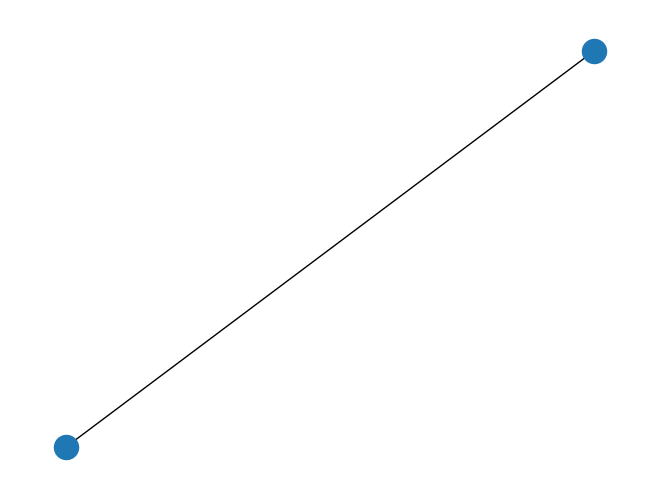

In [4]:
print(f"|V|={len(Graph.graph.nodes())}, |E|={len(Graph.graph.edges())}")
nx.draw(Graph.graph)

To add signals to the nodes or the edges you can instantiate the class as follows.

In [5]:
Graph = GraphInput(nx.path_graph(3), [0, 1, 2],
                   node_signals=[1.0, 0.5, 0.0],
                   edge_signals={(0, 1): 2.0, (1, 2): 1.0})
Graph

GraphInput(graph=<networkx.classes.graph.Graph object at 0x7b2b55356b70>, node_order=[0, 1, 2], node_signals=array([[1. ],
       [0.5],
       [0. ]]), edge_signals={(0, 1): array([2.]), (1, 2): array([1.])})

Then, for scalar signals you can show the signal over the graph with this simple snippet.

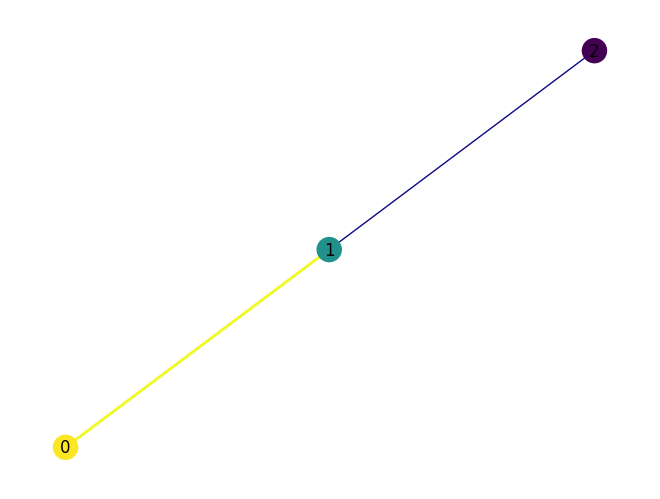

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


edge_values = [
    Graph.edge_signals.get((min(u, v), max(u, v)), np.array([1.0]))[0]
    for u, v in Graph.graph.edges()
    ]

nx.draw(Graph.graph, with_labels=True,
        node_color=Graph.node_signals.flatten(), cmap="viridis",
        edge_color=edge_values, edge_cmap=plt.cm.plasma,
        width=[v for v in edge_values])

plt.show()

Also, arrays of signals are possible.

#### GraphInput Methods
- `adjacency_matrix`: Returns adjacency matrix of the input graph
- `degree_matrix` : Returns degree matrix of the input graph
- `laplacian_matrix` : Returns laplacian matrix of the input graph
- `normalized_laplacian_matrix` : Returns normalized laplacian matrix of the input graph. If $L$ is the laplacian, $A$ the adjacency matrix and $D$ the degree matrix, then the output of this method is $\tilde{L}=I-D^{-\frac{1}{2}}AD^{-\frac{1}{2}}$.
- `kipf_welling_adjacency`: Returns the normalized adjacency with the kipf-welling renomalizationt rick $\hat{A}=\tilde{D}^{-\frac{1}{2}}(A+I)\tilde{D}^{-\frac{1}{2}}$ with adjusted degree matrix $\tilde{D}$ corresponding to the degree matrix of $A+I$.

In [7]:
GraphInput().adjacency_matrix()

array([[0., 1.],
       [1., 0.]])

In [8]:
GraphInput().degree_matrix()

array([[1., 0.],
       [0., 1.]])

In [9]:
GraphInput().laplacian_matrix()

array([[ 1., -1.],
       [-1.,  1.]])

In [10]:
GraphInput().normalized_laplacian_matrix()

array([[ 1., -1.],
       [-1.,  1.]])

In [11]:
GraphInput().kipf_welling_adjacency()


array([[0.5, 0.5],
       [0.5, 0.5]])

Besides these methods there are validations routines that check that the node order specified mathces the number of nodes in the input graph, that analyze signal shapes and run other similar consistency checks. If a validations step fails an error is raised (e.g., a ValueError for an inconsistent node order).

### Functions
Besides auxiliary methods that work in conjunction with the `GraphInput` class (e.g., to flatten vector signals) we have the following graph functions:
- `build_graph_input`:  Build graph from adjacency matrix
- `build_from_adjacency`: Build GraphInput from NetworkX graph.

#### build_graph_input

**Args**
- `graph`: Input graph.
- `node_signals`: Optional node features.
- `edge_signals`: Optional edge features.

**Returns**
- `GraphInput` object.

In [12]:
g = nx.path_graph(2)
build_graph_input(g)

GraphInput(graph=<networkx.classes.graph.Graph object at 0x7b2b550054f0>, node_order=[0, 1], node_signals=None, edge_signals={})

#### build_from_adjacency

**Args**
- `adjacency`: Square symmetric matrix.
- `node_signals`: Optional node features.
- `edge_signals`: Optional edge features.

**Returns**
- `GraphInput` object.

In [13]:
A = [[0., 1.],[1., 0.]]
build_from_adjacency(A)

GraphInput(graph=<networkx.classes.graph.Graph object at 0x7b2b55006210>, node_order=[0, 1], node_signals=None, edge_signals={})